# Project Overview

The Social Media User Analysis was created to observe the effects of social media and well-being on an individual. With the rise of social media and its importance especially among generations such as Millenials, Gen Z, and even Gen Alpha, its effects would be beneficial to consider for individuals, parents, teens, and children alike. For many, it is not enough to say that social media is simply "bad" or "good," hence this project intends to dive deeper into the topic of what makes social media "bad" or "good" for one's health. The project intends to answer the following questions:
* Which age groups spend the most time on social media?
* What factors may cause a user to be on social media more frequent?

### Disclaimer

The data used in this project come from the kaggle dataset located here: https://www.kaggle.com/datasets/rockyt07/social-media-user-analysis
<br>
The data itself contains over 1 million *synthetic* users mimicking real-life usage of Instagram users. This project does not use real Instagram user data and has only been created as a practice for data analysis purposes.

## Import Python Modules

First, the modules in Python used for the project will be imported.

In [1]:
import sqlite3
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import glob

## Loading the SQLite Database

The data needs to be loaded in from the SQLite Database using the `sqlite3.connect` function. Since the data is artificial, it is already clean (unlike real-world data), so no real data cleaning process will be performed for now.

In [2]:
# Connection to database
cnx = sqlite3.connect(r'instagram_users.db')
insta_users = pd.read_sql_query("SELECT * FROM instagram_users", cnx)
pd.set_option('display.max_columns', None)

In [3]:
insta_users.head()

,user_id,app_name,age,gender,country,urban_rural,income_level,employment_status,education_level,relationship_status,has_children,exercise_hours_per_week,sleep_hours_per_night,diet_quality,smoking,alcohol_frequency,perceived_stress_score,self_reported_happiness,body_mass_index,blood_pressure_systolic,blood_pressure_diastolic,daily_steps_count,weekly_work_hours,hobbies_count,social_events_per_month,books_read_per_year,volunteer_hours_per_month,travel_frequency_per_year,daily_active_minutes_instagram,sessions_per_day,posts_created_per_week,reels_watched_per_day,stories_viewed_per_day,likes_given_per_day,comments_written_per_day,dms_sent_per_week,dms_received_per_week,ads_viewed_per_day,ads_clicked_per_day,time_on_feed_per_day,time_on_explore_per_day,time_on_messages_per_day,time_on_reels_per_day,followers_count,following_count,uses_premium_features,notification_response_rate,account_creation_year,last_login_date,average_session_length_minutes,content_type_preference,preferred_content_theme,privacy_setting_level,two_factor_auth_enabled,biometric_login_used,linked_accounts_count,subscription_status,user_engagement_score
0,1,Instagram,51,Female,India,Rural,High,Retired,Bachelor’s,Single,No,7.2,7.7,Good,No,Rarely,3,8,20.8,148,86,8107,49.9,3,4,7,4.3,0,5,1,3,42,28,28,5,12,12,4,1,2,1,1,2,374,647,No,0.34,2015,2025-11-02,5.0,Mixed,Tech,Private,Yes,No,0,Free,7.83
1,2,Instagram,64,Female,United Kingdom,Urban,Middle,Full-time employed,Other,Divorced,No,10.9,8.6,Very poor,No,Rarely,1,1,23.5,133,84,8059,15.6,0,5,10,4.7,2,74,5,3,78,54,68,15,18,10,11,1,31,19,16,19,2585,3511,No,0.56,2018,2025-03-22,14.8,Photos,Fashion,Public,No,No,3,Free,1.43
2,3,Instagram,41,Female,Canada,Urban,Middle,Student,Bachelor’s,In a relationship,No,5.0,6.7,Good,No,Rarely,4,10,28.6,135,88,7872,31.8,4,5,14,1.5,2,5,1,7,29,26,25,6,12,13,4,0,3,1,1,1,3414,6761,No,0.73,2011,2025-08-10,5.0,Mixed,Other,Public,Yes,Yes,1,Free,9.67
3,4,Instagram,27,Non-binary,South Korea,Urban,Middle,Unemployed,Master’s,In a relationship,No,10.6,6.5,Poor,Yes,Never,18,1,22.5,105,73,7801,43.4,2,3,13,3.3,4,233,9,5,241,109,132,36,31,32,33,3,108,64,52,64,617,1193,No,0.73,2019,2025-03-31,25.9,Stories,Tech,Private,No,No,1,Free,0.94
4,5,Instagram,55,Male,India,Urban,Upper-middle,Full-time employed,Bachelor’s,Single,No,7.7,6.8,Average,No,Never,19,1,28.1,146,90,8005,50.2,2,2,12,4.5,3,184,14,5,146,113,103,36,29,37,20,5,78,55,22,55,1157,1072,Yes,0.65,2017,2025-03-19,13.1,Videos,Food,Public,Yes,No,0,Free,1.03


In [4]:
insta_users.shape

(1547896, 58)

In [5]:
insta_users.describe(include='all')

,user_id,app_name,age,gender,country,urban_rural,income_level,employment_status,education_level,relationship_status,has_children,exercise_hours_per_week,sleep_hours_per_night,diet_quality,smoking,alcohol_frequency,perceived_stress_score,self_reported_happiness,body_mass_index,blood_pressure_systolic,blood_pressure_diastolic,daily_steps_count,weekly_work_hours,hobbies_count,social_events_per_month,books_read_per_year,volunteer_hours_per_month,travel_frequency_per_year,daily_active_minutes_instagram,sessions_per_day,posts_created_per_week,reels_watched_per_day,stories_viewed_per_day,likes_given_per_day,comments_written_per_day,dms_sent_per_week,dms_received_per_week,ads_viewed_per_day,ads_clicked_per_day,time_on_feed_per_day,time_on_explore_per_day,time_on_messages_per_day,time_on_reels_per_day,followers_count,following_count,uses_premium_features,notification_response_rate,account_creation_year,last_login_date,average_session_length_minutes,content_type_preference,preferred_content_theme,privacy_setting_level,two_factor_auth_enabled,biometric_login_used,linked_accounts_count,subscription_status,user_engagement_score
count,1.547896e+06,1547896,1.547896e+06,1547896,1547896,1547896,1547896,1547896,1547896,1547896,1547896,1.547896e+06,1.547896e+06,1547896,1547896,1547896,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1547896,1.547896e+06,1.547896e+06,1547896,1.547896e+06,1547896,1547896,1547896,1547896,1547896,1.547896e+06,1547896,1.547896e+06
unique,NaN,1,NaN,4,10,3,5,7,9,5,2,NaN,NaN,5,3,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,369,NaN,6,8,3,2,2,NaN,3,NaN
top,NaN,Instagram,NaN,Male,United States,Urban,Middle,Full-time employed,Bachelor’s,Single,No,NaN,NaN,Average,No,Rarely,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,2025-05-16,NaN,Reels,Fitness,Public,Yes,No,NaN,Free,NaN
freq,NaN,1547896,NaN,743169,386829,850754,465037,629798,541083,670260,1156273,NaN,NaN,543910,1160179,541778,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1206687,NaN,NaN,4382,NaN,258594,194543,516235,1007062,928167,NaN,1160127,NaN
mean,7.739485e+05,NaN,3.898544e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.143480e+00,6.999384e+00,NaN,NaN,NaN,1.998774e+01,5.499804e+00,2.500084e+01,1.244917e+02,7.950007e+01,8.000105e+03,3.622201e+01,2.996140e+00,3.998807e+00,1.000160e+01,3.997591e+00,2.999713e+00,1.882298e+02,1.032897e+01,5.960338e+00,1.756081e+02,1.011600e+02,1.191122e+02,3.421294e+01,2.881592e+01,3.058328e+01,2.005123e+01,4.765017e+00,9.413037e+01,3.762037e+01,3.295203e+01,5.647662e+01,2.160543e+03,2.604942e+03,NaN,5.002404e-01,2.018466e+03,NaN,2.050971e+01,NaN,NaN,NaN,NaN,NaN,1.975254e+00,NaN,1.644642e+00
std,4.468392e+05,NaN,1.529453e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.994556e+00,1.097098e+00,NaN,NaN,NaN,1.183258e+01,2.871232e+00,3.976188e+00,2.020699e+01,1.154874e+01,8.939761e+01,1.508063e+01,1.730508e+00,2.000449e+00,3.160761e+00,2.413619e+00,1.731983e+00,1.101278e+02,7.931112e+00,3.888248e+00,7.622040e+01,3.879075e+01,5.614637e+01,1.746649e+01,1.224658e+01,1.432850e+01,9.864529e+00,3.104442e+00,5.649837e+01,2.535788e+01,2.144569e+01,3.534782e+01,3.402016e+03,2.751922e+03,NaN,2.887827e-01,4.613253e+00,NaN,8.697454e+00,NaN,NaN,NaN,NaN,NaN,1.352058e+00,NaN,1.812684e+00
min,1.000000e+00,NaN,1.300000e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,3.000000e+00,NaN,NaN,NaN,0.000000e+00,1.000000e+00,1.500000e+01,9.000000e+01,6.000000e+01,7.566000e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+

And interesting find at first glance with this database is that it seems the most popular users are single men, whom are fully employed and prefer to view fitness-related content. The average age of seems to be around 39 years old (according to the mean of 3.898544e+01	or 38.985 and median of 3.900000e+01 or 39.0). 
<br>
The column `user_id` can be ignored with its mean, count, etc. because it is a unique identifier and has no agreggate functions. Thus this column, rather than being an int64 column, would make much more sense in being an object column. Other than that, no oddities in the dataframe could be found at first glance.
<br>
<br>
The columns that shows **NaN** represent the unavailability due to functions not being applicable to categorical and/or numerical values. So, it is not, for example, possible to get standard deviation for the country because this is a categorical variable, hence it will show as **NaN** and the same goes for categorical functions (such as unique, top, etc.) trying to be applied to numerical values.

In [6]:
insta_users.dtypes

user_id                             int64
app_name                           object
age                                 int64
gender                             object
country                            object
urban_rural                        object
income_level                       object
employment_status                  object
education_level                    object
relationship_status                object
has_children                       object
exercise_hours_per_week           float64
sleep_hours_per_night             float64
diet_quality                       object
smoking                            object
alcohol_frequency                  object
perceived_stress_score              int64
self_reported_happiness             int64
body_mass_index                   float64
blood_pressure_systolic             int64
blood_pressure_diastolic            int64
daily_steps_count                   int64
weekly_work_hours                 float64
hobbies_count                     

In [7]:
insta_users['user_id'] = insta_users['user_id'].astype(str)

In [8]:
insta_users.dtypes

user_id                            object
app_name                           object
age                                 int64
gender                             object
country                            object
urban_rural                        object
income_level                       object
employment_status                  object
education_level                    object
relationship_status                object
has_children                       object
exercise_hours_per_week           float64
sleep_hours_per_night             float64
diet_quality                       object
smoking                            object
alcohol_frequency                  object
perceived_stress_score              int64
self_reported_happiness             int64
body_mass_index                   float64
blood_pressure_systolic             int64
blood_pressure_diastolic            int64
daily_steps_count                   int64
weekly_work_hours                 float64
hobbies_count                     

## Using Random Samples of the Data

Currently, at over 1 million data points in the dataset, this may be considered on some devices too large of a dataset for speedy rendering and visualization. Therefore, a random sample of 100,000 data points (10% of the data) is generally considered a good measure to notice trends and make reasonable assumptions. The function `df.sample` can be used to randomly select the data.

In [9]:
sample_users = insta_users.sample(frac=0.1)

## Data Analysis

This section of the data will begin the analysis to answer the questions above. Normally, more data cleaning would be done to check for missing data; however, since the data is synthetic, there is no missing data.

The first thing to examine is the age group that is most likely to view Instagram.

In [10]:
sample_users['age'].unique()

# Create bins of each age group based on generation
binned = pd.cut(
    sample_users['age'],
    bins=[-np.inf, 14, 29, 45, 61, np.inf],
    labels=["Gen Alpha (0-14)", "Gen Z (15-29)", "Millenials (30-45)", "Gen X (46-61)", "Boomer (62+)"],
)

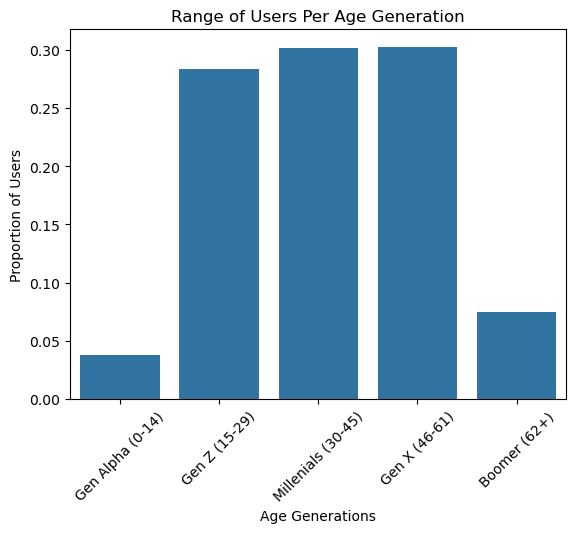

In [11]:
ax = sns.countplot(data=sample_users, x=binned, stat='proportion')
ax.tick_params(axis='x', labelrotation=45)
ax.set_xlabel("Age Generations")
ax.set_ylabel("Proportion of Users")
ax.set_title("Range of Users Per Age Generation")
plt.show()

As shown in the above chart, it seems evident that Millenials take the "winner" of the highest count of users in their age range (at almost 30%) with Gen X not too far behind, suggesting that Millenials are the users that most frequently use Instagram. The surprising observation is that the generation most stereotyped for their social media use, Gen Alpha, is actually of the lowest count (even lower than those born in the "Baby Boomer" generation). 

The next question to be asked then is, what are the factors that cause a user to be on social media more frequent than others? For example, what makes the generation of Millenials more likely to use instagram than the tech-savvy generation of Gen Alpha? This can be answered by examining different factors that makes Instagram seemingly more appealing to the older generation than younger.

## Visual Analysis

This section of the project will use charts to analyze possible theories of why certain generations are more likely to use Instagram than other users. 
<br>
<br>
First, a pie chart will be used to examine which features of Instagram are most used and then be broken down further to see if this holds true to all generations (in other words, if each generation uses the same feature for the same amount of time).

In [12]:
feed_per_day_time = sample_users['time_on_feed_per_day'].sum()
explore_per_day_time = sample_users['time_on_explore_per_day'].sum()
message_per_day_time = sample_users['time_on_messages_per_day'].sum()
reels_per_day_time = sample_users['time_on_reels_per_day'].sum()

# create pie chart labels
labels = ['Feed', 'Explore', 'Messages', 'Reels']
# create pie chart size
sizes = [feed_per_day_time,explore_per_day_time,message_per_day_time,reels_per_day_time]

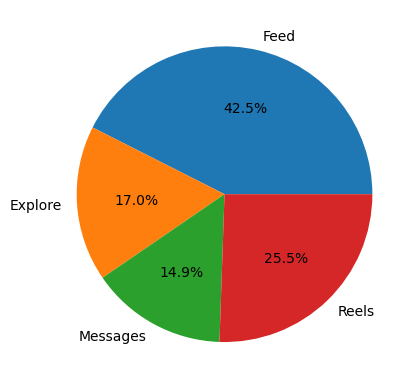

In [13]:
plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.show()

From this chart, it is visually clear that the feed feature in Instagram is used far more than other features. It holds near-half of the pie chart at 42.9%. While it is obvious here that Feed is most used, there could be question whether this holds true per generation. Let's delve deeper into use-case per generation and see if it's true.

In [14]:
# create a new column that separates each age by generation using qcut
sample_users["age_generation"] = pd.cut(sample_users["age"], bins=[0, 14, 29, 45, 61, 120],
                                         labels=["gen_alpha", "gen_z", "millenials", "gen_x", "boomer"])

# create a new dataframe per age generation
gen_alpha_users = sample_users[sample_users["age_generation"] == "gen_alpha"]
gen_z_users = sample_users[sample_users["age_generation"] == "gen_z"]
millenial_users = sample_users[sample_users["age_generation"] == "millenials"]
gen_x_users = sample_users[sample_users["age_generation"] == "gen_x"]
boomer_users = sample_users[sample_users["age_generation"] == "boomer"]

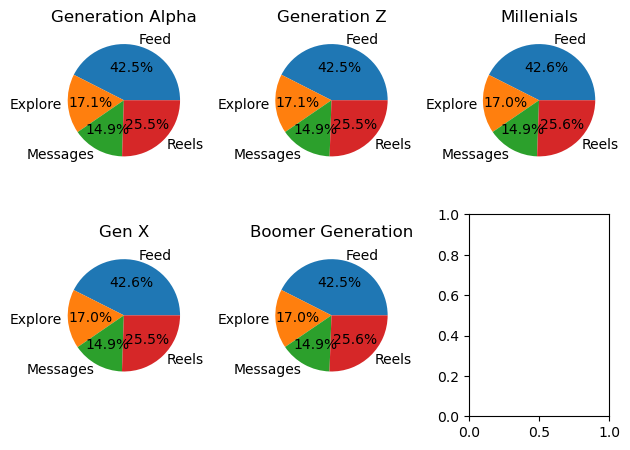

In [15]:
# create a pie chart per age generation
labels = ['Feed', 'Explore', 'Messages', 'Reels']

fig, axs = plt.subplots(2, 3)
axs[0, 0].pie(x=[gen_alpha_users['time_on_feed_per_day'].sum(), gen_alpha_users['time_on_explore_per_day'].sum(), 
                 gen_alpha_users['time_on_messages_per_day'].sum(), gen_alpha_users['time_on_reels_per_day'].sum()]
              , labels=labels, autopct='%1.1f%%')
axs[0, 0].set_title('Generation Alpha')

axs[0, 1].pie(x=[gen_z_users['time_on_feed_per_day'].sum(), gen_z_users['time_on_explore_per_day'].sum(), 
                 gen_z_users['time_on_messages_per_day'].sum(), gen_z_users['time_on_reels_per_day'].sum()]
              , labels=labels, autopct='%1.1f%%')
axs[0, 1].set_title('Generation Z')

axs[0, 2].pie(x=[millenial_users['time_on_feed_per_day'].sum(), millenial_users['time_on_explore_per_day'].sum(), 
                 millenial_users['time_on_messages_per_day'].sum(), millenial_users['time_on_reels_per_day'].sum()]
              , labels=labels, autopct='%1.1f%%')
axs[0, 2].set_title('Millenials')

axs[1, 0].pie(x=[gen_x_users['time_on_feed_per_day'].sum(), gen_x_users['time_on_explore_per_day'].sum(), 
                 gen_x_users['time_on_messages_per_day'].sum(), gen_x_users['time_on_reels_per_day'].sum()]
              , labels=labels, autopct='%1.1f%%')
axs[1, 0].set_title('Gen X')

axs[1, 1].pie(x=[boomer_users['time_on_feed_per_day'].sum(), boomer_users['time_on_explore_per_day'].sum(), 
                 boomer_users['time_on_messages_per_day'].sum(), boomer_users['time_on_reels_per_day'].sum()]
              , labels=labels, autopct='%1.1f%%')
axs[1, 1].set_title('Boomer Generation')


plt.rcParams['font.size'] = 10
plt.tight_layout() 
plt.show()

These pie chart charts show no significant difference in usage of instagram. All generations seem to use feed the most with around 42-43%, and messaging the least by about 15%, which explore and reel usage remains around 26%. Therefore, it can be assumed that types of features within instagram is **not** a good factor that contributes to instagram being used more in one generation than the other. Since instagram's internal features do not seem to be the cause, looking at outside factors--more related to the user than instagram--would be best looked at.

### User Lifestyle Analysis

Some factors outside of instagram, such at the user's lifestyle, could be a bigger contribution to their use of instagram. Therefore, the following columns next will be examined for any sort of correlation between generations and instagram usage.

* `weekly_work_hours`
* `hobbies_count`
* `social_events_per_month`
* `books_read_per_year`
* `volunteer_hours_per_month`
* `travel_frequency_per_year`
* `followers_count`

In [16]:
# Filter out for only needed columns
heatmap_sample = sample_users[['age_generation', 'weekly_work_hours','hobbies_count', 'books_read_per_year', 'volunteer_hours_per_month',
                               'social_events_per_month','travel_frequency_per_year','followers_count']]
#sns.heatmap(df.pivot(index='Y', columns='X', values='Z'))

# pivot the table into a heatmap-compatible style
heat_sample_pivoted = heatmap_sample.pivot_table(
    columns='age_generation', 
    values=['weekly_work_hours','hobbies_count', 'books_read_per_year', 'volunteer_hours_per_month',
            'social_events_per_month','travel_frequency_per_year','followers_count'], 
    aggfunc="mean",
    observed=True)

heat_sample_pivoted

age_generation,gen_alpha,gen_z,millenials,gen_x,boomer
books_read_per_year,9.997261,9.999932,10.002612,9.985943,9.968834
followers_count,2510.471072,2508.662288,2033.287360,2005.249482,1935.883450
hobbies_count,2.977919,3.000000,2.988503,2.998697,2.984892
social_events_per_month,4.004451,3.989007,4.013638,4.007605,4.001036
travel_frequency_per_year,2.963198,2.989258,2.991672,2.987054,2.988345
volunteer_hours_per_month,4.041236,3.991258,4.005288,4.001498,3.946793
weekly_work_hours,0.000000,31.926437,39.973328,39.965120,39.915626


In [17]:
# transform the rows to be divided into proportion (so that each row is equal to 1)
heat_sample_prop = heat_sample_pivoted.div(heat_sample_pivoted.sum(axis=1), axis=0)

heat_sample_prop

age_generation,gen_alpha,gen_z,millenials,gen_x,boomer
books_read_per_year,0.200127,0.200180,0.200234,0.199900,0.199558
followers_count,0.228358,0.228194,0.184953,0.182402,0.176093
hobbies_count,0.199192,0.200669,0.199900,0.200582,0.199658
social_events_per_month,0.200065,0.199294,0.200524,0.200223,0.199895
travel_frequency_per_year,0.198612,0.200359,0.200521,0.200211,0.200298
volunteer_hours_per_month,0.202203,0.199702,0.200404,0.200214,0.197477
weekly_work_hours,0.000000,0.210346,0.263363,0.263309,0.262983


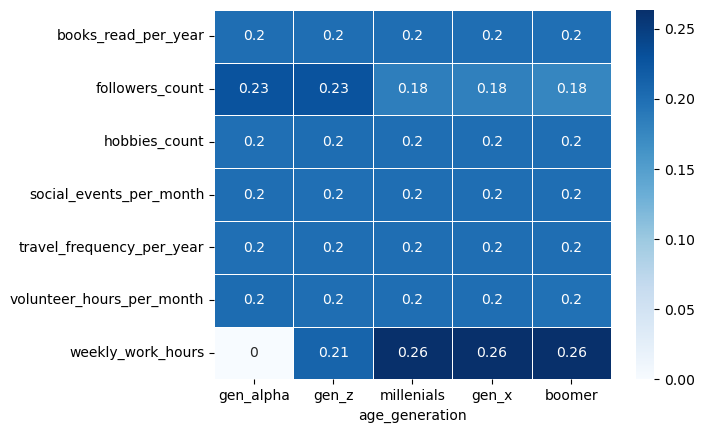

In [18]:
# create the heatmap
sns.heatmap(heat_sample_prop, cmap='Blues', annot=True, linewidth=0.5)
plt.show()

This heatmap reveals that there is no significant correlation between outside lifestyle and instagram usage. On average, gen alpha seems to have more followers than the other generations (24% of all followers belongs to generation alpha in propotion to the other generations), and seem to have all around the same proportion of hobbies, books, social events, travel frequency, and volunteer hours. The only outstanding difference between generation alpha and the others is in regards to `weekly_work_hours` which is 0%. This makes sense because generation alpha are still children and in many countries are not working (choosing to focus on schooling).

## Conclusion

The goal of this project started off as an idea to break stereotypes of generation. Because the project database contained over 1 million values, it was decided best to use a fraction of it (10%) to examine in order to maintain the speed and cleanness of the charting. With this randomly chosen sampled data, the "stereotype" was partially met as the examination of more "technologically-afleunt" generations (such as generation alpha) showed that they are not the dominant users of the social media website Instagram. Following this path, there was a need to examine further on if there was a *reason* why it seems one generation is more attracted than another for reasons other than fluency in technology (the boomer generation, for example, would obviously be less likely to use social media as it is not popular for them to be using technology compared to their successor generations). In this project, pie charts and heat maps were used to see if there was a common factor contributing to popularity within generations. From these charts, it was shown that "internal" factors such as different features of Instagram, nor "external" factors such as work or hobbies, are substantial factors that contribute to usage of Instagram.
<br>
<br>
As disappointing as this conclusion is, it does bring analysis that there may be more factors that could attract some users to social media than others (such as peer usage, celebrity promotion, etc.) but such factors were out of scope for this project.